In [1]:
import numpy as np
import os
import networkx as nx
from matplotlib import pyplot as plt
import torch
import time
from pathlib import Path
import sys

repo_root = next(
    parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (parent / "datagen").exists() and (parent / "baselines").exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from datagen.generateDataset_softinterventions import Dataset
from utils import *
from rpy2 import robjects
from rpy2.robjects import numpy2ri
import rpy2.robjects as robjects

Error importing in API mode: ImportError("dlopen(/Users/alparturkoglu/miniconda3/envs/test_scout/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <20FB70DB-7E84-3375-A520-E0350E06C060> /Users/alparturkoglu/miniconda3/envs/test_scout/lib/python3.11/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


# Select settings and generate the graph

In [2]:
noise_type = 'gumbel' #Choices: 'gaussian', 'gumbel', 'exponential'
intervention_type = 'shift' #Choices: 'shift', 'scale', 'noise'  
sem_type = 'nnl' #Choices: 'lin', 'nnl'
n_nodes = 10
if intervention_type == 'shift':
    shift_scale=2
    intervention_scale=0.5
    noisy = False
elif intervention_type == 'scale':
    shift_scale=0
    intervention_scale=2
    noisy = False
elif intervention_type == 'noise':
    shift_scale=0
    intervention_scale=0.5
    noisy = True
unknown_target = True #If True, intervention targets are unknown during training

In [3]:
dataset_gen = Dataset(
    n_nodes=n_nodes,
    expected_density=2, 
    n_samples=1000,
    n_experiments=n_nodes,
    act_fun='tanh',
    contractive=True,
    target_predef=True,
    targets= [np.array([node]) for node in range(n_nodes)],
    mode = 'sat-pair-condition',
    sem_type=sem_type, 
    shift_scale=shift_scale,
    enforce_dag=False, 
    intervention_scale=intervention_scale,
    noisy=noisy,
    noise_type=noise_type,
    noisy_weight=-1
    )
datasets = dataset_gen.generate(interventions=True)
training_data = datasets
intervention_sets =dataset_gen.targets
n_experiments = len(intervention_sets)
intervention_sets_array = np.zeros((n_experiments, n_nodes))
for i, interv in enumerate(intervention_sets):
    intervention_sets_array[i, interv] = 1

Text(0.5, 1.0, 'Edge weights')

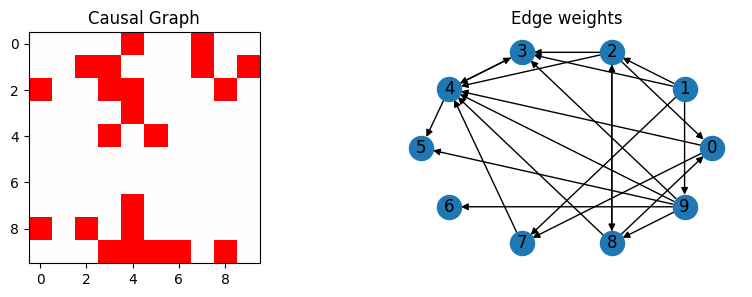

In [4]:
# Visualizing the graph

graph = dataset_gen.graph
sem = dataset_gen.gen_model

pos = nx.circular_layout(graph)

fig, axs = plt.subplots(1, 2)
fig.set_size_inches(10, 3)

if dataset_gen.sem_type == "nnl" or dataset_gen.sem_type == "hyb":
    axs[0].imshow(nx.to_numpy_array(sem.graph), cmap='bwr', vmin=-0.5, vmax=0.5)
    nx.draw(graph, with_labels=True, pos=pos, ax=axs[1])

else:
    axs[0].imshow(sem.weights, cmap='bwr', vmin=-0.5, vmax=0.5)

    axs[1].imshow(sem.weights_i, cmap='bwr', vmin=-0.5, vmax=0.5)
    plt.colorbar(axs[1].images[0], ax=axs[1])

axs[0].set_title("Causal Graph")
axs[1].set_title("Edge weights")

In [5]:
    
def jacobian_sq_empirical(fn, x, max_samples=256, device=None):
    if device is None:
        device = x.device if isinstance(x, torch.Tensor) else 'cpu'
    if not isinstance(x, torch.Tensor):
        x = torch.tensor(x, dtype=torch.float, device=device)
    else:
        x = x.to(device).float()
    if x.ndim == 1:
        x = x.unsqueeze(0)
    N = x.shape[0]
    S = min(N, max_samples)
    def _call(inp):
        out = fn(inp)
        if isinstance(out, tuple):
            out = out[0]
        if out.ndim == 1:
            out = out.unsqueeze(0)
        return out
    y0 = _call(x[0:1])
    out_dim = y0.shape[1]
    in_dim = x.shape[1]
    acc = np.zeros((out_dim, in_dim), dtype=float)
    for k in range(S):
        xs = x[k:k+1].detach().clone().requires_grad_(True)
        ys = _call(xs)        # (1, out_dim)
        yv = ys[0]
        for i in range(yv.shape[0]):
            grad_i = torch.autograd.grad(yv[i], xs, retain_graph=True, create_graph=False)[0]  # (1, in_dim)
            acc[i] += (grad_i.squeeze(0).detach().cpu().numpy() ** 2)
    acc /= float(S)
    return acc

def minmax_normalize(M, eps=1e-12):
    M = np.array(M, dtype=float)
    mn = M.min()
    mx = M.max()
    return (M - mn) / (mx - mn + eps)

if sem_type == "nnl":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    f = dataset_gen.gen_model.f  
    d = n_nodes   
    G = 100 
    vals = torch.linspace(-10.0, 10.0, G, device=device)
    x_grid = torch.zeros(d * G, d, device=device)
    for j in range(d):
        x_grid[j*G:(j+1)*G, j] = vals
    J2_grid = jacobian_sq_empirical(f, x_grid, max_samples=x_grid.shape[0], device=device)
    gt_graph = J2_grid.T
elif sem_type == "lin":
    gt_graph = abs(dataset_gen.gen_model.weights)

# SCOUT

In [6]:
if sem_type == "lin":
    act_fun = 'none'
elif sem_type == "nnl" or sem_type == "hyb":
    act_fun = 'tanh'
from models.scout_trainer import scout_train_test_wrapper
model = scout_train_test_wrapper(
    n_nodes=n_nodes,
    batch_size=512,
    l1_reg=True, 
    lambda_c=1e-3,
    lambda_r=1e-2, # sparsity penalization coef
    fun_type='gst-mlp', # Gumble-softmax masking function
    act_fun=act_fun,
    lr=1e-2,
    epochs=100, # change to a higher number for better accuracy,
    v=True, 
    inline=True, 
    n_hidden=0,
    optim='adam',
    dag_input= False,
    unknown_intervention=unknown_target,
    n_experiments=n_experiments,
    learn_interv=unknown_target,
)


Initializing the model
Number of Parameters : 1432


In [7]:
model.train(training_data, intervention_sets, batch_size=512)

Starting Training
Intervention logits parameter count: 1
Epoch 1/100 Batch 0, Loss 15.0060
Epoch 1/100 Batch 1, Loss 14.8650
Epoch 1/100 Batch 2, Loss 14.8446
Epoch 1/100 Batch 3, Loss 14.6465
Epoch 1/100 Batch 4, Loss 14.7678
Epoch 1/100 Batch 5, Loss 14.1460
Epoch 1/100 Batch 6, Loss 14.4522
Epoch 1/100 Batch 7, Loss 14.3997
Epoch 1/100 Batch 8, Loss 14.0724
Epoch 1/100 Batch 9, Loss 13.9924
Epoch 1/100 Batch 10, Loss 13.9967
Epoch 1/100 Batch 11, Loss 13.9524
Epoch 1/100 Batch 12, Loss 13.7988
Epoch 1/100 Batch 13, Loss 13.7531
Epoch 1/100 Batch 14, Loss 13.6830
Epoch 1/100 Batch 15, Loss 13.7709
Epoch 1/100 Batch 16, Loss 13.4088
Epoch 1/100 Batch 17, Loss 13.4569
Epoch 1/100 Batch 18, Loss 13.2706
Epoch 1/100 Batch 19, Loss 13.4589
Epoch 1/100 time: 0:00:00 (0.58s)
Epoch 2/100 Batch 0, Loss 13.2399
Epoch 2/100 Batch 1, Loss 13.0857
Epoch 2/100 Batch 2, Loss 13.1359
Epoch 2/100 Batch 3, Loss 13.1431
Epoch 2/100 Batch 4, Loss 12.9881
Epoch 2/100 Batch 5, Loss 12.9058
Epoch 2/100 Bat

SHD: 4.0
AUPRC: 0.9396282809747516


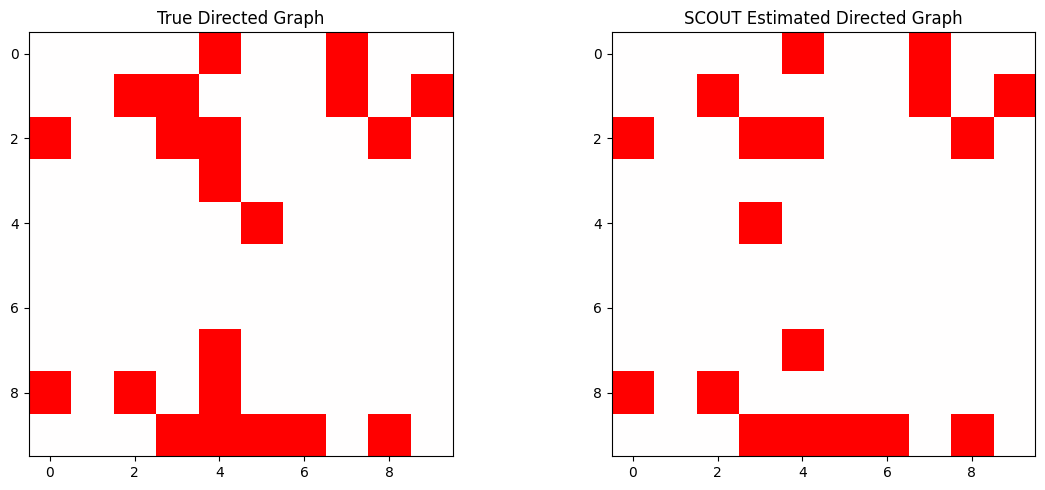

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

if sem_type == "lin":
    axs[0].imshow(nx.to_numpy_array(sem.graph)>0, cmap='bwr', vmin=-0.5, vmax=0.5)
elif sem_type == "nnl":
    axs[0].imshow(J2_grid.T>0.001, cmap='bwr', vmin=-0.5, vmax=0.5)
axs[0].set_title("True Directed Graph")

adjacency_matrix = model.model.return_adjacency().detach().cpu().numpy()
axs[1].imshow(adjacency_matrix>0.5, cmap='bwr', vmin=-1, vmax=1)
axs[1].set_title("SCOUT Estimated Directed Graph")

plt.tight_layout()

# Compute SHD
if sem_type == "nnl":
    shd = compute_shd(J2_grid.T>0.001, adjacency_matrix > 0.5)
elif sem_type == "lin":
    shd = compute_shd(np.abs(gt_graph) > 0, adjacency_matrix > 0.5)
print(f"SHD: {shd[0]}")
if sem_type == "nnl":
    _, auprc = compute_auprc(J2_grid.T>0.001, np.abs(adjacency_matrix))
elif sem_type == "lin":
    _, auprc = compute_auprc(np.abs(gt_graph) > 0, np.abs(adjacency_matrix))
print(f"AUPRC: {auprc}")


SHD between true and estimated graph: 0.0
AUPRC between true and estimated graph: 1.0


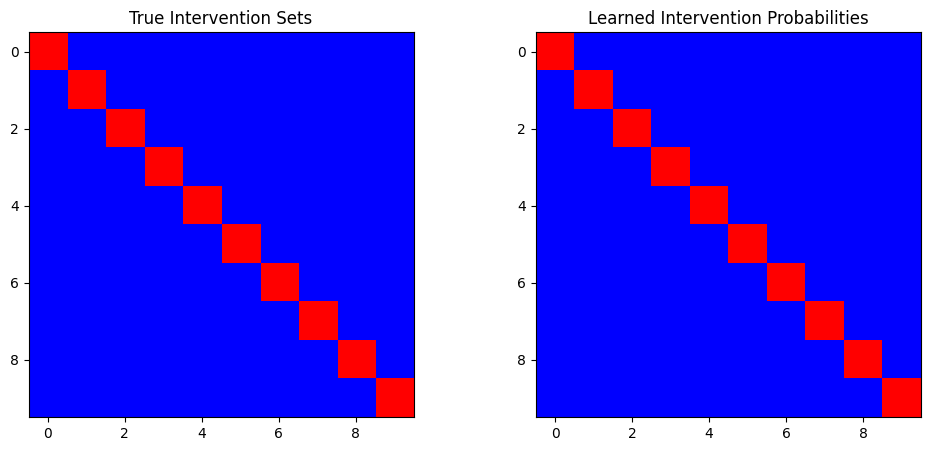

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(intervention_sets_array, cmap='bwr', vmin=0, vmax=1)
axs[0].set_title("True Intervention Sets") 
proba = model.model.trained_interv.get_proba()
axs[1].imshow(proba.detach().cpu().numpy()>0.5, cmap='bwr', vmin=0, vmax=1)
axs[1].set_title("Learned Intervention Probabilities")
shd = compute_shd(intervention_sets_array>0.001, proba.detach().cpu().numpy() > 0.5)
print(f"SHD between true and estimated graph: {shd[0]}")
auprc = compute_auprc(intervention_sets_array>0.001, proba.detach().cpu().numpy())
print(f"AUPRC between true and estimated graph: {auprc[1]}")

# NODAGS

In [10]:
from pathlib import Path
import sys

repo_root = next(
    parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (parent / "baselines" / "nodags" / "models" / "resblock_trainer.py").exists()
)
nodags_root = repo_root / "baselines" / "nodags"
if str(nodags_root) not in sys.path:
    sys.path.insert(0, str(nodags_root))

from models.resblock_trainer import resflow_train_test_wrapper

if sem_type == "lin":
    act_fun = 'none'
elif sem_type == "nnl":
    act_fun = 'tanh'
model = resflow_train_test_wrapper(
    n_nodes=10,
    batch_size=512,
    l1_reg=True, 
    lambda_c=1e-3,
    fun_type='gst-mlp', # Gumble-softmax masking function
    act_fun=act_fun,
    lr=1e-2,
    epochs=100, # change to a higher number for better accuracy,
    v=False, 
    inline=True, 
    n_hidden=0,
    optim='adam',
    dag_input=False,
)

Initializing the model
Number of Parameters : 212


In [11]:
if unknown_target:
    intervention_sets = [[None] for _ in range(n_experiments)]

In [12]:
model.train(training_data, intervention_sets, batch_size=512)

Starting Training


SHD: 46.0
AUPRC: 0.22596657418572164


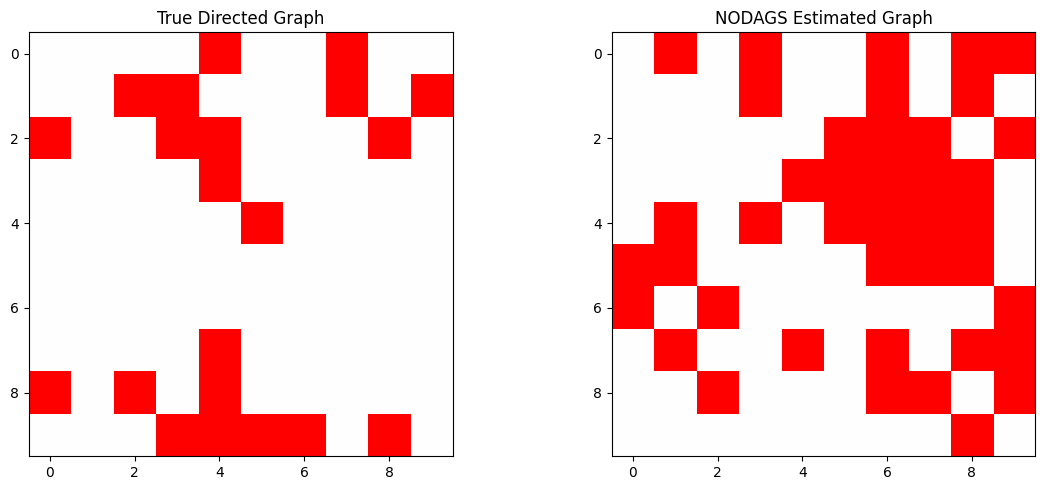

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

if sem_type == "lin":
    axs[0].imshow(nx.to_numpy_array(sem.graph)>0, cmap='bwr', vmin=-0.5, vmax=0.5)
elif sem_type == "nnl":
    axs[0].imshow(J2_grid.T>0.001, cmap='bwr', vmin=-0.5, vmax=0.5)
axs[0].set_title("True Directed Graph")

adjacency_matrix = model.model.f.get_w_adj().detach().cpu().numpy()
axs[1].imshow(adjacency_matrix>0.5, cmap='bwr', vmin=-1, vmax=1)
axs[1].set_title("NODAGS Estimated Graph")

plt.tight_layout()

# Compute SHD
if sem_type == "nnl":
    shd = compute_shd(J2_grid.T>0.001, adjacency_matrix > 0.5)
elif sem_type == "lin":
    shd = compute_shd(np.abs(gt_graph) > 0, adjacency_matrix > 0.9)
print(f"SHD: {shd[0]}")
if sem_type == "nnl":
    _, auprc = compute_auprc(J2_grid.T>0.001, np.abs(adjacency_matrix))
elif sem_type == "lin":
    _, auprc = compute_auprc(np.abs(gt_graph) > 0, np.abs(adjacency_matrix))
print(f"AUPRC: {auprc}")

## LLC

In [14]:
print(os.getcwd())
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parents[1]
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from baselines.llc import LLCClassWrapper
llc_wrapper = LLCClassWrapper()

/Users/alparturkoglu/Desktop/SCOUT/SCOUT-master/notebooks
/Users/alparturkoglu/Desktop/SCOUT/SCOUT-master/notebooks


In [15]:
B_est = llc_wrapper.train(datasets, dataset_gen.targets, return_weights=True)

Parsing experiments
Estimating the adjacency matrix
Estimating latent variances


SHD: 20.0
LLC AUPRC: 0.3076075262841342


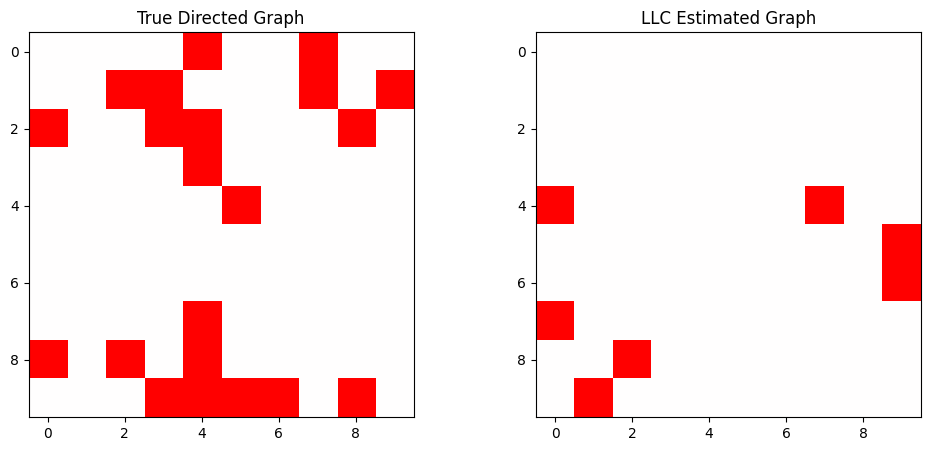

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))  

if sem_type == "lin":
    axs[0].imshow(nx.to_numpy_array(sem.graph)>0, cmap='bwr', vmin=-0.5, vmax=0.5)
elif sem_type == "nnl":
    axs[0].imshow(J2_grid.T>0.001, cmap='bwr', vmin=-0.5, vmax=0.5)
axs[0].set_title("True Directed Graph")

axs[1].imshow(np.abs(B_est)>0.05, cmap='bwr', vmin=-0.5, vmax=0.5)
axs[1].set_title("LLC Estimated Graph")

# Compute SHD
if sem_type == "nnl" or sem_type == "hyb":
    shd = compute_shd(J2_grid.T>0.001, abs(B_est) > 0.05)
    _, auprc = compute_auprc(J2_grid.T>0.001, abs(B_est))
elif sem_type == "lin":
    shd = compute_shd(np.abs(gt_graph) > 0, abs(B_est) > 0.05)
print(f"SHD: {shd[0]}")
print(f"LLC AUPRC: {auprc}")

# BACKSHIFT

In [17]:
X_list = []
ExpInd = []
for exp_idx, dataset in enumerate(datasets):
    X_list.append(dataset)
    ExpInd.extend([exp_idx + 1] * dataset.shape[0])
X = np.vstack(X_list)
ExpInd = np.array(ExpInd)

repo_root = next(
    parent for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (parent / "baselines" / "backShift-master").exists()
)
bsdir = repo_root / "baselines" / "backShift-master" / "R"
so_path = repo_root / "baselines" / "backShift-master" / "src" / "backShift.so"

with (robjects.default_converter + numpy2ri.converter).context():
    robjects.r('library(igraph)')
    robjects.r('library(clue)')    
    source_order = [
        "ffdiag.R", "computeVarEnv.R", "computeDelta.R", "hasCycles.R", 
        "generateA.R", "edgeSelection.R", "addCycle.R", "permuteAndScale.R",
        "checkDiagonalization.R", "bootstrap.R", "metrics.R", "plotting_helpers.R",
        "plotGraph.R", "plotInterventionVar.R", "simulate.R", "backShift.R"
    ]
    for r_file in source_order:
        abs_path = bsdir / r_file
        if not abs_path.exists():
            raise FileNotFoundError(f"R file not found: {abs_path}")
        robjects.r(f'source("{abs_path}")')    
    robjects.r(f'dyn.load("{so_path}")')
    robjects.globalenv['X_data'] = X
    robjects.globalenv['ExpInd_vec'] = robjects.IntVector(ExpInd)
    robjects.r('''
    result <- backShift(X_data, ExpInd_vec, covariance=TRUE, verbose=FALSE)
    ''')
    Ahat = np.array(robjects.r('result$Ahat'))
    Learned_interv = np.array(robjects.r('result$varianceEnv'))
    robjects.r('''
    result_verify <- backShift(X_data, ExpInd_vec, covariance=TRUE, verbose=FALSE, baseSettingEnv=2)
    ''')
    Learned_inter_verify = np.array(robjects.r('result_verify$varianceEnv'))


R callback write-console: 
Attaching package: ‘igraph’

  
R callback write-console: The following objects are masked from ‘package:stats’:

    decompose, spectrum

  
R callback write-console: The following object is masked from ‘package:base’:

    union

  
R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1: `graph.adjacency()` was deprecated in igraph 2.0.0.
ℹ Please use `graph_from_adjacency_matrix()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
  
R callback write-console: 2: `is.dag()` was deprecated in igraph 2.0.0.
ℹ Please use `is_dag()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
  


SHD between true and estimated graph: 25.0
AUPRC between true and estimated graph: 0.2569946626669316


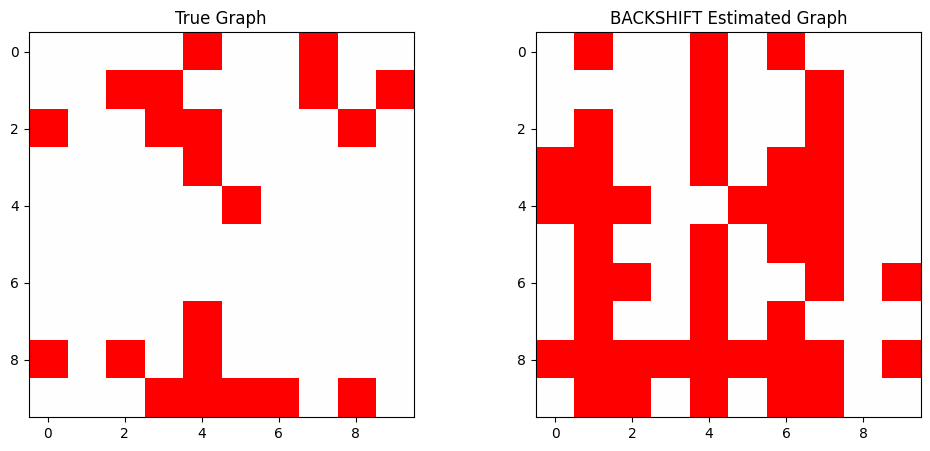

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(J2_grid.T>0.001, cmap='bwr', vmin=-0.5, vmax=0.5)
axs[0].set_title("True Graph")
axs[1].imshow(Ahat>0.01, cmap='bwr', vmin=-1, vmax=1)
axs[1].set_title("BACKSHIFT Estimated Graph")
shd = compute_shd(J2_grid.T>0.001, Ahat > 0.1)
print(f"SHD between true and estimated graph: {shd[0]}")
auprc = compute_auprc(J2_grid.T>0.001, Ahat)
print(f"AUPRC between true and estimated graph: {auprc[1]}")

SHD between true and estimated graph: 9.0
AUPRC between true and estimated graph: 0.9


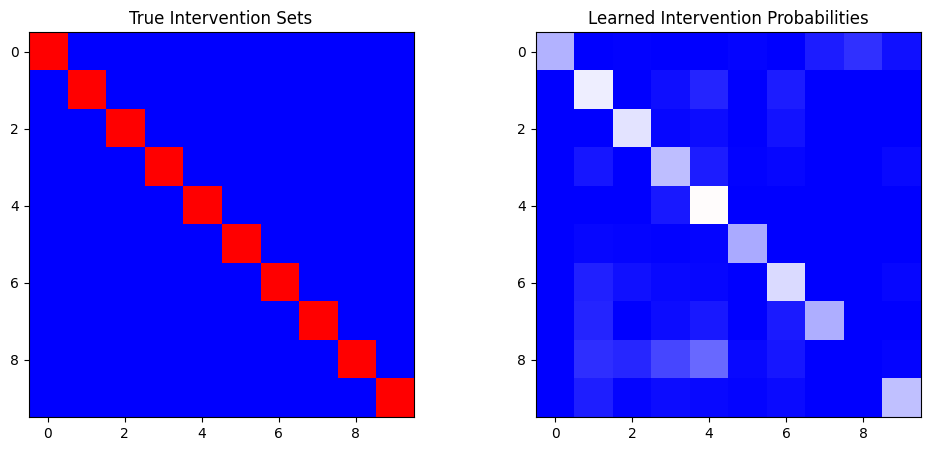

In [19]:
Learned_interv[0, :] = Learned_interv[0, :] + Learned_inter_verify[0, :]
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(intervention_sets_array, cmap='bwr', vmin=0, vmax=1)
axs[0].set_title("True Intervention Sets") 
axs[1].imshow(Learned_interv, cmap='bwr', vmin=0, vmax=1)
axs[1].set_title("Learned Intervention Probabilities")
shd = compute_shd(intervention_sets_array>0.001, Learned_interv > 0.5)
print(f"SHD between true and estimated graph: {shd[0]}")
auprc = compute_auprc(intervention_sets_array>0.001, Learned_interv)
print(f"AUPRC between true and estimated graph: {auprc[1]}")